In [153]:
from IPython.core.display import Markdown
from dotenv import load_dotenv
from langchain_community.chat_models import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.graph import StateGraph
from src.States import GlobalState, Car, TelemetryData
from src.States import TrackData
from typing import *
import random
from langgraph.constants import START,END
from IPython.core.display import Image
import copy

load_dotenv()

True

In [154]:
sysmessage = SystemMessage(f"You are an AI agent that is being used for simulating AI F1 cars to a extent, your job is to be as a Race Engineer, you should also take into consideration about the lap times you can create, Take your current position into account. You can try for undercut. Lap time is determined by laptime = generatelaptime + (TyreDegradation/100)*2 + if gap less than 1 random.random() + (fuelrem/totalfuel)*2, think what the other cars might do and TyreDegradation of 100 means puncture and time is +20seconds. You need to choose wet when weather is wet")

LaptimeModel = ChatOpenAI(model="gpt-4.1-nano-2025-04-14",temperature=0)
laptime_sysmessage=SystemMessage("You are a laptime generating AI agent that uses the car's telemetry data and trackdata to find the approx laptime in seconds that varies between +-1 second of benchmark time and give only the value in seconds and have a precision of 3 digits in the milliseconds. if the TyreDegradation goes above 100 add 20 to the laptime ")


In [172]:
MOCK_TRACK_DATA: List[TrackData] = [
    {
        "TrackID": 1,
        "TrackName": "Monaco",

        "Soft_Deg": 8.1,
        "Medium_Deg": 6.67,
        "Hard_Deg": 5.1,
        "Wet_Deg": 7.1,

        "Soft_Lap": 113.5,
        "Medium_Lap": 115.5,
        "Hard_Lap": 117.5,
        "Wet_Lap": 137.5,

        "PitLoss": 19.3,
        "FuelLoss": 2.3,
        "TotalFuel": 69,
    },
    {
        "TrackID": 2,
        "TrackName": "Great Britain",
        "Soft_Deg": 10.25,
        "Medium_Deg": 9.1,
        "Hard_Deg": 7.8,
        "Wet_Deg": 9.5,
        "Soft_Lap": 146.5,
        "Medium_Lap": 149.5,
        "Hard_Lap": 151.5,
        "Wet_Lap": 164.5,
        "PitLoss": 20.2,
        "FuelLoss": 3.4,
        "TotalFuel": 102,
    },
    {
        "TrackID": 3,
        "TrackName": "Abu Dhabi",
        "Soft_Deg": 10.25,
        "Medium_Deg": 8.25,
        "Hard_Deg": 6.75,
        "Wet_Deg": 7.1,
        "Soft_Lap": 145.5,
        "Medium_Lap": 148.5,
        "Hard_Lap": 150.5,
        "Wet_Lap": 162.5,
        "PitLoss": 21.7,
        "FuelLoss": 3.7,
        "TotalFuel": 111,
    },
]

MOCK_CAR_LIST: List[Car] = [
    {
        "CarPosition": 1,
        "CarID": 4,  # Lando Norris
        "Team": "McLaren",
        "Telemetry": None,
        "Driver": "Lando Norris",
        "TotalRaceTime": 0.0,
        "isUser": False,
    },
    {
        "CarPosition": 2,
        "CarID": 1,  # Max Verstappen
        "Team": "RedBull",
        "Telemetry": None,
        "Driver": "Max Verstappen",
        "TotalRaceTime": 0.0,
        "isUser": False,
    },
    {
        "CarPosition": 3,
        "CarID": 63,  # George Russell
        "Team": "Mercedes",
        "Telemetry": None,
        "Driver": "George Russell",
        "TotalRaceTime": 0.0,
        "isUser": False,
    },
    {
        "CarPosition": 4,
        "CarID": 81,  # Oscar Piastri
        "Team": "McLaren",
        "Telemetry": None,
        "Driver": "Oscar Piastri",
        "TotalRaceTime": 0.0,
        "isUser": False,
    },
    {
        "CarPosition": 5,
        "CarID": 12,  # Andrea Kimi Antonelli
        "Team": "Mercedes",
        "Telemetry": None,
        "Driver": "Kimi Antonelli",
        "TotalRaceTime": 0.0,
        "isUser": False,
    },
    {
        "CarPosition": 6,
        "CarID": 22,  # Yuki Tsunoda
        "Team": "RedBull",
        "Telemetry": None,
        "Driver": "Yuki Tsunoda",
        "TotalRaceTime": 0.0,
        "isUser": False,
    },
]

In [173]:
def select_track(state: GlobalState) -> dict:
    """This tool is used to select the user track and define it in all the global"""
    selection = int(input("Select Track: \n1. Monaco\n2. Great Britain\n3. Abu Dhabi\n"))
    while selection not in [1,2,3]:
        selection = int(input("Pls Select a Valid Track\nSelect Track: \n1. Monaco\n2. Great Britain\n3. Abu Dhabi\n"))

    Markdown(f"Selected Track: {selection}")

    return {"Track" : MOCK_TRACK_DATA[selection-1]}

def random_weather(state: GlobalState) -> dict:
    """This tool is used to randomly select a weather station and define it in all the global"""
    weather = random.choice(["Wet","Dry"])

    Markdown(f"Weather Generated: {weather}")

    return {"Weather" : weather}

def create_cars(state: GlobalState) -> dict:
    """This tool is used to create cars and assign a car based on the input"""


    cars = copy.deepcopy(MOCK_CAR_LIST)
    # -----------------------

    selection = int(input(
        """--- Select a Driver ---\n\t1. Lando Norris (McLaren)\n\t2. Max Verstappen (RedBull)
        \t3. George Russell (Mercedes)\n\t4. Oscar Piastri (McLaren)\n\t5. Andrea Kimi Antonelli (Mercedes)
        \t6. Yuki Tsunoda (RedBull)\n----------------------------\nEnter the position number of the driver: """))
    while selection not in [1,2,3,4,5,6]:
        selection = int(input(
        """--- Select a Driver ---\n\t1. Lando Norris (McLaren)\n\t2. Max Verstappen (RedBull)
        \t3. George Russell (Mercedes)\n\t4. Oscar Piastri (McLaren)\n\t5. Andrea Kimi Antonelli (Mercedes)
        \t6. Yuki Tsunoda (RedBull)\n----------------------------\nEnter the position number of the driver: """))

    Markdown(f"😊😊 Selected Driver: {selection} 😊😊")


    cars[selection-1]["isUser"] = True

    return {"Cars": cars,"UserCar": cars[selection-1]}

In [181]:
def race_briefing(state: GlobalState) -> dict:
    """This node summarizes the race setup."""
    print("\n==========================================")
    print("           🏁 RACE BRIEFING 🏁            ")
    print("==========================================")


    track = state['Track']
    print(f"TRACK: {track['TrackName']}")
    print(f"   - Soft Deg: {track['Soft_Deg']}per lap | Lap Time: {track['Soft_Lap']}s")
    print(f"   - Med  Deg: {track['Medium_Deg']}per lap | Lap Time: {track['Medium_Lap']}s")
    print(f"   - Hard Deg: {track['Hard_Deg']}per lap | Lap Time: {track['Hard_Lap']}s")
    print(f"   - Wet  Deg: {track['Wet_Deg']}per lap  | Lap Time: {track['Wet_Lap']}s")
    print(f"   - Pit Loss: {track['PitLoss']}s")


    print(f"\n☁️ WEATHER: {state['Weather']}")

    user_car = state['UserCar']
    print(f"\n🏎️ YOUR CAR: {user_car['Driver']} ({user_car['Team']})")

    return {}

def select_tyre(State: GlobalState) -> dict:
    """This tool is used to select a tyre based on the input for the user car"""
    selection = int(input(f"Select a tyre for your car\n "
                          f"Track: {State['Track']['TrackName']}\nWeather: {State["Weather"]}\n\t 1. Soft (deg: {State['Track']['Soft_Deg']})\n\t 2. Medium (deg: {State['Track']['Medium_Deg']})\n\t 3. Hard (deg: {State['Track']['Hard_Deg']})\n\t 4. Wet (deg: {State["Track"]["Wet_Deg"]})"))
    while selection not in [1,2,3,4]:
        selection = int(input(f"Select a tyre for your car\n "
                          f"Track: {State['Track']['TrackName']}\nWeather: {State["Weather"]}\n\t 1. Soft (deg: {State['Track']['Soft_Deg']})\n\t 2. Medium (deg: {State['Track']['Medium_Deg']})\n\t 3. Hard (deg: {State['Track']['Hard_Deg']})\n\t 4. Wet (deg: {State["Track"]["Wet_Deg"]})"))

    car = State['UserCar']

    initial_telemetry : TypedDict[TelemetryData] = {
        "Tyre": "Soft",
        "TyreLaps": 0,
        "TyreDegradation": 0,
        "laps_remaining": State['TotalLaps'],
        "LastLapTime": 0.0,
        "FuelRemaining": State['Track']['TotalFuel'],
    }

    if selection == 1:
        initial_telemetry["Tyre"] = "Soft"
    elif selection == 2:
        initial_telemetry["Tyre"] = "Medium"
    elif selection == 3:
        initial_telemetry["Tyre"] = "Hard"
    else:
        initial_telemetry["Tyre"] = "Wet"

    car['Telemetry'] = initial_telemetry

    return {"UserCar": car}

def generate_telemetry(State: GlobalState) -> dict:
    """This tool is used to generate telemetry for the AI controlled cars"""


    cars = State['Cars']
    for car in cars:
        if not car['isUser']:
            model = ChatOpenAI(model="gpt-4o",temperature=0)
            initial_telemetry : TypedDict[TelemetryData] = {
                "Tyre": None,
                "TyreLaps": 0,
                "TyreDegradation": 0,
                "laps_remaining": State['TotalLaps'],
                "LastLapTime": 0.0,
                "FuelRemaining": State['Track']['TotalFuel'],
            }
            car['Telemetry'] = initial_telemetry

            input_messages = [sysmessage,HumanMessage(f"{State['Track']} and {State['Weather']} and {initial_telemetry}, the tyre deg is amt per lap so based on this data choose a tyre that will be suitable for your car. Give the answer as Soft, Medium, Hard or Wet for your car in one word. you need to use 2 different tyre compounds")]
            res = model.invoke(input_messages)
            #print(res)
            car['Telemetry']["Tyre"] = res.content

    return {"Cars": cars}

def generate_grid(State: GlobalState) -> dict:
    """This tool is used to generate grid of telemetry for the cars"""
    cars = State['Cars']
    random.shuffle(cars)
    i = 1
    for car in cars:
        car['CarPosition'] = i
        i += 1

    return {"Cars": cars}

def print_grid(State: GlobalState) -> dict:
    """This tool is used to Print the grid of the cars"""
    print("\n==========================================")
    print("           🏁 RACE GRID 🏁            ")
    print("==========================================")

    i=0
    for car in State['Cars']:
        if i % 2 == 0:
            print(f" ____________________ ")
            print(f"|                    |")
            print(f"| {car['CarID']:^19}|")
            print(f"| {car['Driver']:^19}|")

        else:
            print(f"\t\t\t\t\t\t ____________________ ")
            print(f"\t\t\t\t\t\t|                    |")
            print(f"\t\t\t\t\t\t| {car['CarID']:^19}|")
            print(f"\t\t\t\t\t\t| {car['Driver']:^19}|")
        i+=1

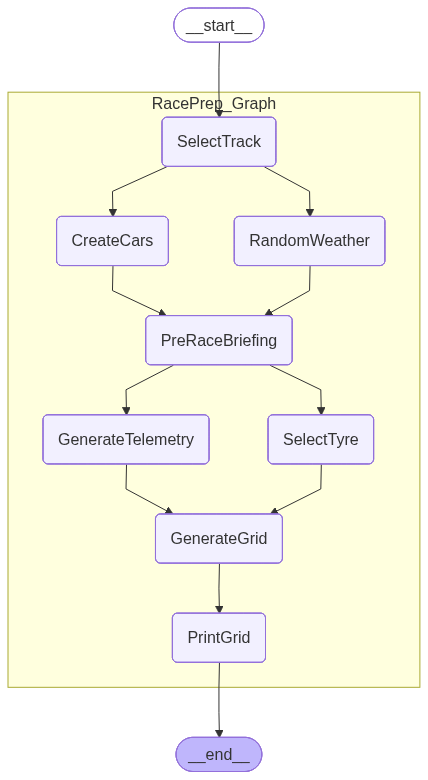

In [182]:
main_builder=StateGraph(GlobalState)

RacePrep = StateGraph(GlobalState)

RacePrep.add_node("SelectTrack", select_track)
RacePrep.add_node("RandomWeather", random_weather)
RacePrep.add_node("CreateCars", create_cars)
RacePrep.add_node("PreRaceBriefing",race_briefing)
RacePrep.add_node("SelectTyre", select_tyre)
RacePrep.add_node("GenerateTelemetry", generate_telemetry)
RacePrep.add_node("GenerateGrid", generate_grid)
RacePrep.add_node("PrintGrid", print_grid)


RacePrep.add_edge(START,"SelectTrack")
RacePrep.add_edge("SelectTrack","RandomWeather")
RacePrep.add_edge("SelectTrack","CreateCars")
RacePrep.add_edge("RandomWeather","PreRaceBriefing")
RacePrep.add_edge("CreateCars","PreRaceBriefing")
RacePrep.add_edge("PreRaceBriefing","SelectTyre")
RacePrep.add_edge("PreRaceBriefing","GenerateTelemetry")
RacePrep.add_edge("SelectTyre","GenerateGrid")
RacePrep.add_edge("GenerateTelemetry","GenerateGrid")
RacePrep.add_edge("GenerateGrid","PrintGrid")
RacePrep.add_edge("PrintGrid",END)


RacePrep_Graph = RacePrep.compile()

main_builder.add_node("RacePrep_Graph", RacePrep_Graph)

main_builder.add_edge(START,"RacePrep_Graph")
main_builder.add_edge("RacePrep_Graph",END)

graph = main_builder.compile()

display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [183]:
SampleInput = {
    "Cars": "",
    "Track": "",
    "CurrentLap": 0,
    "TotalLaps": 63,
    "RaceOver": False
}
result=""
try:
    result = graph.invoke(SampleInput)
except:
    print("Something went wrong")


           🏁 RACE BRIEFING 🏁            
TRACK: Monaco
   - Soft Deg: 8.1per lap | Lap Time: 113.5s
   - Med  Deg: 6.67per lap | Lap Time: 115.5s
   - Hard Deg: 5.1per lap | Lap Time: 117.5s
   - Wet  Deg: 7.1per lap  | Lap Time: 137.5s
   - Pit Loss: 19.3s

☁️ WEATHER: Wet

🏎️ YOUR CAR: Lando Norris (McLaren)

           🏁 RACE GRID 🏁            
 ____________________ 
|                    |
|          1         |
|   Max Verstappen   |
						 ____________________ 
						|                    |
						|         63         |
						|   George Russell   |
 ____________________ 
|                    |
|         81         |
|    Oscar Piastri   |
						 ____________________ 
						|                    |
						|          4         |
						|    Lando Norris    |
 ____________________ 
|                    |
|         22         |
|    Yuki Tsunoda    |
						 ____________________ 
						|                    |
						|         12         |
						|   Kimi Antonelli   |


In [184]:
result

{'Cars': [{'CarPosition': 1,
   'CarID': 1,
   'Team': 'RedBull',
   'Telemetry': {'Tyre': 'Wet',
    'TyreLaps': 0,
    'TyreDegradation': 0,
    'laps_remaining': 63,
    'LastLapTime': 0.0,
    'FuelRemaining': 69},
   'Driver': 'Max Verstappen',
   'TotalRaceTime': 0.0,
   'isUser': False},
  {'CarPosition': 2,
   'CarID': 63,
   'Team': 'Mercedes',
   'Telemetry': {'Tyre': 'Wet',
    'TyreLaps': 0,
    'TyreDegradation': 0,
    'laps_remaining': 63,
    'LastLapTime': 0.0,
    'FuelRemaining': 69},
   'Driver': 'George Russell',
   'TotalRaceTime': 0.0,
   'isUser': False},
  {'CarPosition': 3,
   'CarID': 81,
   'Team': 'McLaren',
   'Telemetry': {'Tyre': 'Wet',
    'TyreLaps': 0,
    'TyreDegradation': 0,
    'laps_remaining': 63,
    'LastLapTime': 0.0,
    'FuelRemaining': 69},
   'Driver': 'Oscar Piastri',
   'TotalRaceTime': 0.0,
   'isUser': False},
  {'CarPosition': 4,
   'CarID': 4,
   'Team': 'McLaren',
   'Telemetry': {'Tyre': 'Soft',
    'TyreLaps': 0,
    'TyreDegrada